In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
## Step 1: Load and Preprocess Data

# Define transformations for images
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

In [4]:
# Load Fashion-MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


In [5]:
# Get the shape of the first image in the training dataset
image, label = train_dataset[0]
print(image.shape)
print(len(train_dataset))

torch.Size([1, 28, 28])
60000


In [6]:
# Get the shape of the first image in the test dataset
image, label = test_dataset[0]
print(image.shape)
print(len(test_dataset))

torch.Size([1, 28, 28])
10000


In [7]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [8]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1=nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
        # conv2 should take 32 channels as input from conv1's output after pooling
        self.conv2=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        # conv3 should take 64 channels as input from conv2's output after pooling
        self.conv3=nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        # Calculate input size for fc1: 128 channels * 3x3 feature map after 3 pooling layers
        # (28 -> 14 -> 7 -> 3) based on kernel_size=2, stride=2
        self.fc1=nn.Linear(128*3*3,128)
        self.fc2=nn.Linear(128,64)
        self.fc3=nn.Linear(64,10)

    def forward(self, x):
      x=self.pool(torch.relu(self.conv1(x)))
      x=self.pool(torch.relu(self.conv2(x)))
      x=self.pool(torch.relu(self.conv3(x)))
      x=x.view(x.size(0),-1)
      x=torch.relu(self.fc1(x))
      x=torch.relu(self.fc2(x))
      x=self.fc3(x)
      return x

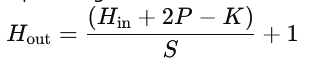

In [9]:
from torchsummary import summary

# Initialize model
model = CNNClassifier()

# Move model to GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)

# Print model summary
print('Name:SURYANARAYANAN T')
print('Register Number:212224040341')
summary(model, input_size=(1, 28, 28))

Name:SURYANARAYANAN T
Register Number:212224040341
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
         MaxPool2d-2           [-1, 32, 14, 14]               0
            Conv2d-3           [-1, 64, 14, 14]          18,496
         MaxPool2d-4             [-1, 64, 7, 7]               0
            Conv2d-5            [-1, 128, 7, 7]          73,856
         MaxPool2d-6            [-1, 128, 3, 3]               0
            Linear-7                  [-1, 128]         147,584
            Linear-8                   [-1, 64]           8,256
            Linear-9                   [-1, 10]             650
Total params: 249,162
Trainable params: 249,162
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.42
Params size (MB): 0.95
Estimated Total Size (MB

In [10]:
# Initialize model, loss function, and optimizer
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
## Step 3: Train the Model
def train_model(model, train_loader, num_epochs=3):
    for epoch in range(num_epochs):
      model.train()
      running_loss = 0.0
      for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print('Name:SURYANARAYANAN T')
    print('Register Number:212224040341')
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')


In [12]:
# Train the model
train_model(model, train_loader)

Name:SURYANARAYANAN T
Register Number:212224040341
Epoch [3/3], Loss: 0.2399


In [17]:
## Step 4: Test the Model
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print('Name:SURYANARAYANAN T')
    print('Register Number:212224040341')
    print(f'Test Accuracy: {accuracy:.4f}')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    print('Name:SURYANARAYANAN T')
    print('Register Number:212224040341')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print('Name:SURYANARAYANAN T')
    print('Register Number:212224040341')
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))


Name:SURYANARAYANAN T
Register Number:212224040341
Test Accuracy: 0.9079
Name:SURYANARAYANAN T
Register Number:212224040341


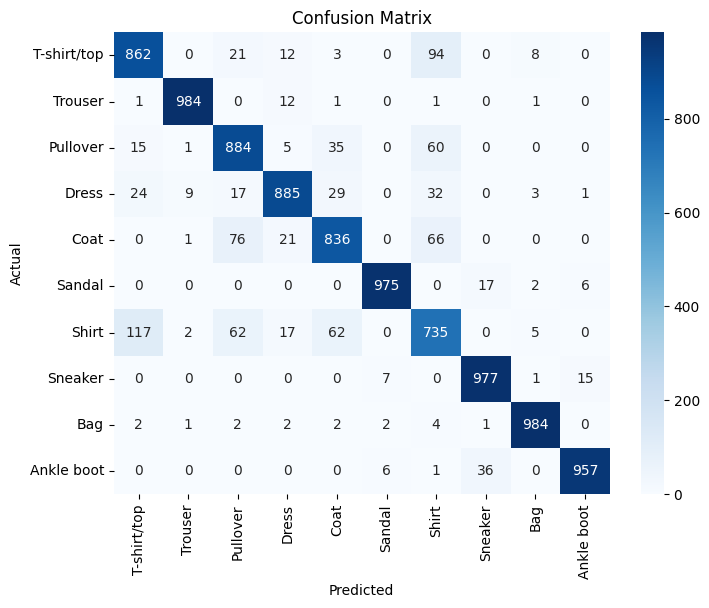

Name:SURYANARAYANAN T
Register Number:212224040341
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.83      0.88      0.86      1000
       Dress       0.93      0.89      0.91      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.74      0.73      0.74      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [18]:
# Evaluate the model
test_model(model, test_loader)


In [15]:
## Step 5: Predict on a Single Image
import matplotlib.pyplot as plt
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    with torch.no_grad():
        output = model(image.unsqueeze(0))  # Add batch dimension
        _, predicted = torch.max(output, 1)
    class_names = dataset.classes

    # Display the image
    print('Name:SURYANARAYANAN T')
    print('Register Number:212224040341')
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()
    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')


Name:SURYANARAYANAN T
Register Number:212224040341


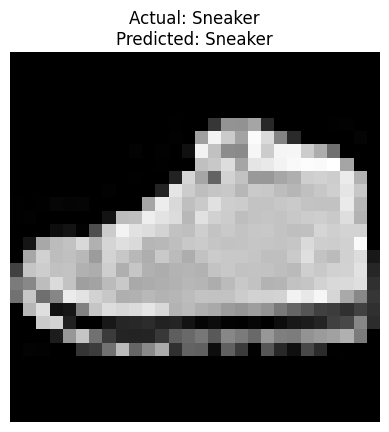

Actual: Sneaker, Predicted: Sneaker


In [16]:
# Example Prediction
predict_image(model, image_index=331, dataset=test_dataset)

# Task
Define the class names for the Fashion-MNIST dataset.

## Define Fashion-MNIST class names

### Subtask:
Define a list of class names for the Fashion-MNIST dataset.


## Summary:

### Data Analysis Key Findings
*   The class names for the Fashion-MNIST dataset were defined as follows: 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', and 'Ankle boot'.

### Insights or Next Steps
*   Proceed to load and explore the Fashion-MNIST dataset, utilizing these defined class names for better interpretability.


# Task
Load and preprocess the Fashion-MNIST dataset for model training.

## Define Image Transformations

### Subtask:
Define the necessary image transformations for the Fashion-MNIST dataset, including converting images to tensors and normalizing them.


## Create DataLoaders

### Subtask:
Create `DataLoader` instances for both the training and testing datasets to handle batching and shuffling.


## Final Task

### Subtask:
Confirm that the data has been successfully loaded and preprocessed, and is ready for model training.


## Summary:

### Q&A
The data has been successfully loaded and preprocessed, and is ready for model training.

### Data Analysis Key Findings
*   Image transformations, including converting images to tensors and normalizing them with a mean of 0.5 and a standard deviation of 0.5, were already defined and in place.
*   `DataLoader` instances for both training and testing datasets were successfully created with a batch size of 32.
*   The training `DataLoader` was configured with shuffling enabled, while the testing `DataLoader` had shuffling disabled, as appropriate for model training and evaluation.

### Insights or Next Steps
*   The Fashion-MNIST dataset is fully prepared and ready for immediate use in model training due to the successful completion of all preprocessing steps.
*   The next logical step is to proceed with defining, training, and evaluating a machine learning model using the prepared data loaders.
